In [2]:
!pip install torch_snippets torch_summary --quiet

In [11]:
import itertools
import torch
from PIL import Image
from torch_snippets import *
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchsummary import summary

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

(256, 256)

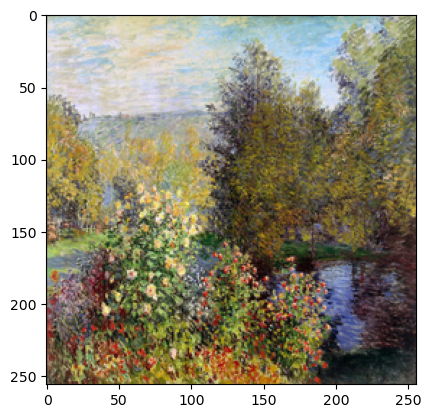

In [18]:
import matplotlib.pyplot as plt

img = Image.open('./HW_06 Dataset/trainA/00001.jpg')
plt.imshow(img)
img.size

In [23]:
IMAGE_SIZE = 256
transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE*1.33)),
    transforms.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


## Load Monet_to_Photo Dataset

In [54]:
import os
import glob
import random

class Monet2PhotoDataset(Dataset):
    def __init__(self, monets_dir, photos_dir):
        self.monets = glob.glob(os.path.join(monets_dir, '*.jpg'))
        self.photos = glob.glob(os.path.join(photos_dir, '*.jpg'))

    def __getitem__(self, ix):
        monet = self.monets[ix % len(self.monets)]
        photo = random.choice(self.photos)

        monet = Image.open(monet).convert('RGB')
        photo = Image.open(photo).convert('RGB')
        return monet, photo

    def __len__(self): return max(len(self.monets), len(self.photos))
    def choose(self): return self[random.randint(len(self))]

    def collate_fn(self, batch):
        srcs, trgs = list(zip(*batch))
        srcs = torch.cat([transform(img)[None] for img in srcs], 0).to(device).float()
        trgs = torch.cat([transform(img)[None] for img in trgs], 0).to(device).float()

        return srcs.to(device), trgs.to(device)
        
trainA_dir = "./HW_06 Dataset/trainA"
trainB_dir = "./HW_06 Dataset/trainB"
testA_dir = "./HW_06 Dataset/testA"
testB_dir = "./HW_06 Dataset/testB"

# Create dataset instances
train_ds = Monet2PhotoDataset(trainA_dir, trainB_dir)
val_ds = Monet2PhotoDataset(testA_dir, testB_dir)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=train_ds.collate_fn)
val_loader = DataLoader(val_ds, batch_size=5, shuffle=False, collate_fn=val_ds.collate_fn)

for monet_batch, photo_batch in train_loader:
    print(f"Monet batch shape: {monet_batch.shape}")
    print(f"Photo batch shape: {photo_batch.shape}")
    break


Monet batch shape: torch.Size([1, 3, 256, 256])
Photo batch shape: torch.Size([1, 3, 256, 256])


## Cycle Gan training

In [55]:
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)
    elif classname.find("BatchNorm2d") != -1:
        torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(m.bias.data, 0.0)

Residual Block

In [56]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()

        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
        )

    def forward(self, x):
        return x + self.block(x)

Generator Class

In [57]:
class GeneratorResNet(nn.Module):
    def __init__(self, num_residual_blocks=9):
        super(GeneratorResNet, self).__init__()
        out_features = 64
        channels = 3
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(channels, out_features, 7),
            nn.InstanceNorm2d(out_features),
            nn.ReLU(inplace=True),
        ]
        in_features = out_features
        # Downsampling
        for _ in range(2):
            out_features *= 2
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features

        # Residual blocks
        for _ in range(num_residual_blocks):
            model += [ResidualBlock(out_features)]

        # Upsampling
        for _ in range(2):
            out_features //= 2
            model += [
                nn.Upsample(scale_factor=2),
                nn.Conv2d(in_features, out_features, 3, stride=1, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features

        # Output layer
        model += [nn.ReflectionPad2d(channels), nn.Conv2d(out_features, channels, 7), nn.Tanh()]
        self.model = nn.Sequential(*model)
        self.apply(weights_init_normal)
    def forward(self, x):
        return self.model(x)

Discriminator Class

In [58]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        channels, height, width = 3, IMAGE_SIZE, IMAGE_SIZE

        def discriminator_block(in_filters, out_filters, normalize=True):
            """Returns downsampling layers of each discriminator block"""
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(channels, 64, normalize=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1)
        )
        self.apply(weights_init_normal)

    def forward(self, img):
        return self.model(img)


Generate Samples from Cycle GAN

In [59]:
@torch.no_grad()
def generate_sample():
    data = next(iter(val_dl))
    G_AB.eval()
    G_BA.eval()

    real_A, real_B = data
    fake_B = G_AB(real_A)
    fake_A = G_BA(real_B)
    # Arange images along x-axis
    real_A = make_grid(real_A, nrow=5, normalize=True)
    real_B = make_grid(real_B, nrow=5, normalize=True)
    fake_A = make_grid(fake_A, nrow=5, normalize=True)
    fake_B = make_grid(fake_B, nrow=5, normalize=True)
    # Arange images along y-axis
    image_grid = torch.cat((real_A, fake_B, real_B, fake_A), 1)
    show(image_grid.detach().cpu().permute(1,2,0).numpy(), sz=12)

Generator Training Step

In [60]:
def generator_train_step(Gs, optimizer, real_A, real_B):
    G_AB, G_BA = Gs
    optimizer.zero_grad()
    loss_id_A = criterion_identity(G_BA(real_A), real_A)
    loss_id_B = criterion_identity(G_AB(real_B), real_B)

    loss_identity = (loss_id_A + loss_id_B) / 2
    fake_B = G_AB(real_A)
    loss_GAN_AB = criterion_GAN(D_B(fake_B), torch.Tensor(np.ones((len(real_A), 1, 16, 16))).to(device))
    fake_A = G_BA(real_B)
    loss_GAN_BA = criterion_GAN(D_A(fake_A), torch.Tensor(np.ones((len(real_A), 1, 16, 16))).to(device))

    loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2
    recov_A = G_BA(fake_B)
    loss_cycle_A = criterion_cycle(recov_A, real_A)
    recov_B = G_AB(fake_A)
    loss_cycle_B = criterion_cycle(recov_B, real_B)

    loss_cycle = (loss_cycle_A + loss_cycle_B) / 2
    loss_G = loss_GAN + lambda_cyc * loss_cycle + lambda_id * loss_identity
    loss_G.backward()
    optimizer.step()
    return loss_G, loss_identity, loss_GAN, loss_cycle, loss_G, fake_A, fake_B

Discriminator Training Step

In [61]:
def discriminator_train_step(D, real_data, fake_data, optimizer):
    optimizer.zero_grad()
    loss_real = criterion_GAN(D(real_data), torch.Tensor(np.ones((len(real_data), 1, 16, 16))).to(device))
    loss_fake = criterion_GAN(D(fake_data.detach()), torch.Tensor(np.zeros((len(real_data), 1, 16, 16))).to(device))
    loss_D = (loss_real + loss_fake) / 2
    loss_D.backward()
    optimizer.step()
    return loss_D

In [62]:
G_AB = GeneratorResNet().to(device)
G_BA = GeneratorResNet().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

criterion_GAN = torch.nn.MSELoss()
criterion_cycle = torch.nn.L1Loss()
criterion_identity = torch.nn.L1Loss()

optimizer_G = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=0.0002, betas=(0.5, 0.999)
)
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=0.0002, betas=(0.5, 0.999))

lambda_cyc, lambda_id = 10.0, 5.0

Training

In [63]:
import time

n_epochs = 20
for epoch in range(n_epochs):
    epoch_start_time = time.time()  # Track epoch start time
    N = len(train_loader)
    
    running_loss_D = 0.0
    running_loss_G = 0.0
    running_loss_GAN = 0.0
    running_loss_cycle = 0.0
    running_loss_identity = 0.0

    for bx, batch in enumerate(train_loader):
        real_A, real_B = batch

        # Training step for generator
        loss_G, loss_identity, loss_GAN, loss_cycle, loss_G, fake_A, fake_B = generator_train_step((G_AB, G_BA), optimizer_G, real_A, real_B)

        # Training step for discriminator A
        loss_D_A = discriminator_train_step(D_A, real_A, fake_A, optimizer_D_A)

        # Training step for discriminator B
        loss_D_B = discriminator_train_step(D_B, real_B, fake_B, optimizer_D_B)

        # Average discriminator loss
        loss_D = (loss_D_A + loss_D_B) / 2

        # Accumulate losses for reporting later
        running_loss_D += loss_D.item()
        running_loss_G += loss_G.item()
        running_loss_GAN += loss_GAN.item()
        running_loss_cycle += loss_cycle.item()
        running_loss_identity += loss_identity.item()

        # Print loss for the current batch (optional)
        print(f"Epoch {epoch + 1}/{n_epochs} | Batch {bx + 1}/{N} | "
              f"Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f} | "
              f"Loss GAN: {loss_GAN.item():.4f} | Loss Cycle: {loss_cycle.item():.4f} | "
              f"Loss Identity: {loss_identity.item():.4f}", end='\r')

    # At the end of each epoch, print the average losses
    epoch_loss_D = running_loss_D / N
    epoch_loss_G = running_loss_G / N
    epoch_loss_GAN = running_loss_GAN / N
    epoch_loss_cycle = running_loss_cycle / N
    epoch_loss_identity = running_loss_identity / N

    # Time taken for the epoch
    epoch_time = time.time() - epoch_start_time

    # Print average losses and time for the current epoch
    print(f"\nEpoch {epoch + 1}/{n_epochs} completed | "
          f"Avg Loss D: {epoch_loss_D:.4f} | Avg Loss G: {epoch_loss_G:.4f} | "
          f"Avg Loss GAN: {epoch_loss_GAN:.4f} | Avg Loss Cycle: {epoch_loss_cycle:.4f} | "
          f"Avg Loss Identity: {epoch_loss_identity:.4f} | Time: {epoch_time:.2f}s")

    # Optionally, generate a sample image after each epoch
    generate_sample()


OutOfMemoryError: CUDA out of memory. Tried to allocate 18.00 MiB. GPU 0 has a total capacity of 12.00 GiB of which 0 bytes is free. Of the allocated memory 18.55 GiB is allocated by PyTorch, and 74.63 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)